In [1]:
# import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# change the directory below to be able to read the data at your end 
df_clean = pd.read_csv(r"C:\Users\Dell\Documents\my_linux\repos_\asset_financing_risk_prediction\asset_financing\data\processed\clean.csv")

### Feature Engineering

#### Impute missing values effectively.

In [4]:
# check for missing values
df_clean.isna().sum()

SK_ID_CURR                    0
TARGET                        0
CODE_GENDER                   0
FLAG_OWN_CAR                  0
AMT_INCOME_TOTAL              0
AMT_CREDIT                    0
AMT_ANNUITY                  12
NAME_INCOME_TYPE              0
NAME_EDUCATION_TYPE           0
FLAG_PHONE                    0
CNT_FAM_MEMBERS               2
REG_CITY_NOT_LIVE_CITY        0
AMT_REQ_CREDIT_BUREAU_MON     0
AMT_REQ_CREDIT_BUREAU_QRT     0
dtype: int64

In [5]:
# drop missing values because they are less than 5% of the total sample in that specific row
df_clean.dropna(inplace=True)

#### Create relevant features (e.g., Debt-to-Income, payment ratios).

In [6]:
# compute payment ratio ratio
df_clean["PAYMENT_RATIO"] = round(df_clean["AMT_INCOME_TOTAL"] / df_clean["AMT_CREDIT"], 2)

#### Encode categorical variables.

In [7]:
# Encode the following columns:
# 'CODE_GENDER'
cg_dict = list(df_clean['CODE_GENDER'].unique())
cg_result = {i:v for i,v in enumerate(cg_dict)}
cg_result = {v:i for i,v in cg_result.items()}
df_clean["CODE_GENDER"] = df_clean["CODE_GENDER"].replace(cg_result)
cg_result

C:\Users\Dell\AppData\Local\Temp\ipykernel_8456\2913451584.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean["CODE_GENDER"] = df_clean["CODE_GENDER"].replace(cg_result)


{'M': 0, 'F': 1, 'XNA': 2}

In [8]:
# encode 'NAME_INCOME_TYPE'
it_dict = list(df_clean['NAME_INCOME_TYPE'].unique())
it_result = {i:v for i,v in enumerate(it_dict)}
it_result = {v:i for i,v in it_result.items()}
df_clean["NAME_INCOME_TYPE"] = df_clean["NAME_INCOME_TYPE"].replace(it_result)
it_result

C:\Users\Dell\AppData\Local\Temp\ipykernel_8456\2763092069.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean["NAME_INCOME_TYPE"] = df_clean["NAME_INCOME_TYPE"].replace(it_result)


{'Working': 0,
 'State servant': 1,
 'Commercial associate': 2,
 'Pensioner': 3,
 'Unemployed': 4,
 'Student': 5,
 'Businessman': 6,
 'Maternity leave': 7}

In [9]:
# encode 'NAME_EDUCATION_TYPE'
net_dict = list(df_clean['NAME_EDUCATION_TYPE'].unique())
net_result = {i:v for i,v in enumerate(net_dict)}
net_result = {v:i for i,v in net_result.items()}
df_clean["NAME_EDUCATION_TYPE"] = df_clean["NAME_EDUCATION_TYPE"].replace(net_result)
net_result

C:\Users\Dell\AppData\Local\Temp\ipykernel_8456\129370330.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean["NAME_EDUCATION_TYPE"] = df_clean["NAME_EDUCATION_TYPE"].replace(net_result)


{'Secondary / secondary special': 0,
 'Higher education': 1,
 'Incomplete higher': 2,
 'Lower secondary': 3,
 'Academic degree': 4}

In [10]:
# encode  'FLAG_OWN_CAR'
foc_dict = list(df_clean['FLAG_OWN_CAR'].unique())
foc_result = {i:v for i,v in enumerate(foc_dict)}
foc_result = {v:i for i,v in foc_result.items()}
df_clean["FLAG_OWN_CAR"] = df_clean["FLAG_OWN_CAR"].replace(foc_result)
foc_result

C:\Users\Dell\AppData\Local\Temp\ipykernel_8456\1234961999.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean["FLAG_OWN_CAR"] = df_clean["FLAG_OWN_CAR"].replace(foc_result)


{'N': 0, 'Y': 1}

In [11]:
df_clean["TARGET"] = df_clean["TARGET"].astype(int)
df_clean.info() 

<class 'pandas.core.frame.DataFrame'>
Index: 307497 entries, 0 to 307510
Data columns (total 15 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   SK_ID_CURR                 307497 non-null  int64  
 1   TARGET                     307497 non-null  int32  
 2   CODE_GENDER                307497 non-null  int64  
 3   FLAG_OWN_CAR               307497 non-null  int64  
 4   AMT_INCOME_TOTAL           307497 non-null  float64
 5   AMT_CREDIT                 307497 non-null  float64
 6   AMT_ANNUITY                307497 non-null  float64
 7   NAME_INCOME_TYPE           307497 non-null  int64  
 8   NAME_EDUCATION_TYPE        307497 non-null  int64  
 9   FLAG_PHONE                 307497 non-null  bool   
 10  CNT_FAM_MEMBERS            307497 non-null  float64
 11  REG_CITY_NOT_LIVE_CITY     307497 non-null  bool   
 12  AMT_REQ_CREDIT_BUREAU_MON  307497 non-null  float64
 13  AMT_REQ_CREDIT_BUREAU_QRT  307497 

### Modelling

In [12]:
from xgboost import XGBClassifier
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, precision_score,\
     roc_curve, roc_auc_score, recall_score

##### Address class imbalance.

In [13]:
# Handle Class Imbalance
# separate majority and minority class
df_majority = df_clean[df_clean["TARGET"] == 0]
df_minority = df_clean[df_clean["TARGET"] == 1]

In [14]:
# Downsample majority class
df_majority_downsampled = resample(
    df_majority,
    replace=False,              # sample without replacement
    n_samples=len(df_minority), # match minority class size
    random_state=42             # reproducibility
)

In [15]:
# combine the minority class with the down sampled majority class
df_downsampled = pd.concat([df_majority_downsampled, df_minority])

# Shuffle the dataset
df_downsampled = df_downsampled.sample(frac=0.4, random_state=42).reset_index(drop=True)
print("Original class distribution:\n", df_clean["TARGET"].value_counts())
print("Downsampled class distribution:\n", df_downsampled["TARGET"].value_counts())

Original class distribution:
 TARGET
0    282672
1     24825
Name: count, dtype: int64
Downsampled class distribution:
 TARGET
1    9939
0    9921
Name: count, dtype: int64


In [16]:
# check for duplicates
df_downsampled.duplicated().sum()

0

In [17]:
# split the dataset for training and testing
X = df_downsampled.drop("TARGET", axis=1)
y = df_downsampled["TARGET"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
test_pred_ids = X_test["SK_ID_CURR"]
X_train = X_train.drop("SK_ID_CURR", axis = 1)
X_test = X_test.drop("SK_ID_CURR", axis = 1)
X = X.drop("SK_ID_CURR", axis = 1)

#### Train and compare at least two models (e.g., Random Forest, XGBoost).

In [18]:
# instantiate classifier algorithm
rfc = RandomForestClassifier(n_estimators=200, random_state=42)
xgb = XGBClassifier(n_estimators=200, random_state=42)

In [19]:
# train random forest classifier
rfc.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [21]:
y_pred_rfc = rfc.predict(X_test)

In [22]:
print("Results for Random Forest Classifier")
print("precision score:\n", precision_score(y_test, y_pred_rfc))
print("recall score:\n", recall_score(y_test, y_pred_rfc))
print("roc_auc score:\n", roc_auc_score(y_test, y_pred_rfc))
print(classification_report(y_test, y_pred_rfc))

Results for Random Forest Classifier
precision score:
 0.5637931034482758
recall score:
 0.5574497101943403
roc_auc score:
 0.569633946006261
              precision    recall  f1-score   support

           0       0.58      0.58      0.58      3025
           1       0.56      0.56      0.56      2933

    accuracy                           0.57      5958
   macro avg       0.57      0.57      0.57      5958
weighted avg       0.57      0.57      0.57      5958



In [23]:
# train xgboost classifier
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [24]:
y_pred_xgb = xgb.predict(X_test)

In [25]:
print("Results for XGBoost Classifier")
print("precision score:\n", precision_score(y_test, y_pred_xgb))
print("recall score:\n", recall_score(y_test, y_pred_xgb))
print("roc_auc score:\n", roc_auc_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

Results for XGBoost Classifier
precision score:
 0.5744193653909061
recall score:
 0.5987043982270712
roc_auc score:
 0.584310876799486
              precision    recall  f1-score   support

           0       0.59      0.57      0.58      3025
           1       0.57      0.60      0.59      2933

    accuracy                           0.58      5958
   macro avg       0.58      0.58      0.58      5958
weighted avg       0.58      0.58      0.58      5958



##### standardize and retrain algorithms

In [26]:
# instantiate classifier algorithm
rfc_std = RandomForestClassifier(n_estimators=200, random_state=42)
xgb_std = XGBClassifier(n_estimators=200, random_state=42)

In [27]:
# instantiate standardscaler object
stand = StandardScaler()
# standardize X_train
X_train_std = stand.fit_transform(X_train)
X_test_std = stand.transform(X_test)

In [28]:
# train with standardize data
rfc_std.fit(X_train_std, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [29]:
y_pred_rfc_std = rfc_std.predict(X_test_std)
print("Results for Random Forest Classifier after Standardization")
print("precision score:\n", precision_score(y_test, y_pred_rfc_std))
print("recall score:\n", recall_score(y_test, y_pred_rfc_std))
print("roc_auc score:\n", roc_auc_score(y_test, y_pred_rfc_std))
print(classification_report(y_test, y_pred_rfc_std))

Results for Random Forest Classifier after Standardization
precision score:
 0.5634482758620689
recall score:
 0.557108762359359
roc_auc score:
 0.5692981828325722
              precision    recall  f1-score   support

           0       0.58      0.58      0.58      3025
           1       0.56      0.56      0.56      2933

    accuracy                           0.57      5958
   macro avg       0.57      0.57      0.57      5958
weighted avg       0.57      0.57      0.57      5958



In [30]:
# train xgboost classifier based on standardize data
xgb_std.fit(X_train_std, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [31]:
y_pred_xgb_std = xgb_std.predict(X_test_std)
print("Results for XGBoost Classifier")
print("precision score:\n", precision_score(y_test, y_pred_xgb_std))
print("recall score:\n", recall_score(y_test, y_pred_xgb_std))
print("roc_auc score:\n", roc_auc_score(y_test, y_pred_xgb_std))
print(classification_report(y_test, y_pred_xgb_std))

Results for XGBoost Classifier
precision score:
 0.5744193653909061
recall score:
 0.5987043982270712
roc_auc score:
 0.584310876799486
              precision    recall  f1-score   support

           0       0.59      0.57      0.58      3025
           1       0.57      0.60      0.59      2933

    accuracy                           0.58      5958
   macro avg       0.58      0.58      0.58      5958
weighted avg       0.58      0.58      0.58      5958



#### Use cross-validation and show metric performance (e.g., ROC AUC, Precision, Recall).

In [32]:
# initiate the algorithm
model_rfc = RandomForestClassifier(n_estimators=300, random_state=42)
model_xgb = XGBClassifier(n_estimators=300, random_state=42)
# instantiate kfold object
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [33]:
# Evaluate using cross-validation for random forest
scores = cross_val_score(model_rfc, X, y, cv=skf, scoring="precision")
scores

array([0.57640333, 0.56563609, 0.58389963, 0.5742268 , 0.56624606])

In [34]:
# Evaluate using cross-validation for xgboost
scores = cross_val_score(model_xgb, X, y, cv=skf, scoring="precision")
scores

array([0.58832117, 0.576717  , 0.58661216, 0.57772152, 0.5860161 ])

In [35]:
# Test predictions
test_preds = xgb.predict_proba(X_test)[:,1]
# Create submission DataFrame
submission = pd.DataFrame({
    "SK_ID_CURR" : test_pred_ids,
    "TARGET" : test_preds
})

# Save submission file
submission.to_csv("submission.csv", index=False)
print("Submission file saved as 'submission.csv'")

Submission file saved as 'submission.csv'


### Model Interpretation

##### Use SHAP or permutation importance to explain model predictions.

##### Highlight top predictive features and explain their relevance.

In [36]:
# feature importance for baseline random forest
result_rfc = permutation_importance(rfc, X_test, y_test, n_repeats=10, random_state = 42)
# Display importance
importance_df_rfc = pd.DataFrame({
    'feature': X.columns,\
    'mean_importance': result_rfc.importances_mean,\
    'std_importance': result_rfc.importances_std,\
}).sort_values(by='mean_importance', ascending=False)

print("Feature importnace for baseline Random Forest Algorithm")
importance_df_rfc

Feature importnace for baseline Random Forest Algorithm


,feature,mean_importance,std_importance
5,NAME_INCOME_TYPE,0.013360,0.004690
0,CODE_GENDER,0.013008,0.003959
4,AMT_ANNUITY,0.010926,0.004506
3,AMT_CREDIT,0.009634,0.003578
6,NAME_EDUCATION_TYPE,0.009399,0.004162
9,REG_CITY_NOT_LIVE_CITY,0.006412,0.001956
1,FLAG_OWN_CAR,0.003693,0.003005
11,AMT_REQ_CREDIT_BUREAU_QRT,0.001829,0.002373
8,CNT_FAM_MEMBERS,0.001544,0.002087
7,FLAG_PHONE,-0.000470,0.002980


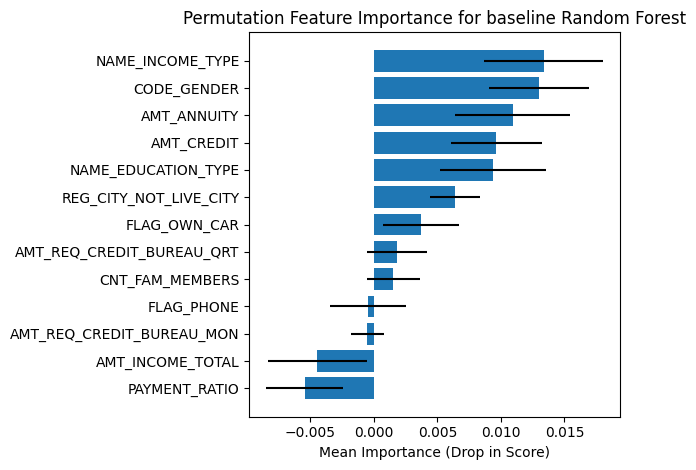

In [37]:
plt.barh(importance_df_rfc["feature"], importance_df_rfc["mean_importance"], xerr=importance_df_rfc["std_importance"])
plt.xlabel("Mean Importance (Drop in Score)")
plt.title("Permutation Feature Importance for baseline Random Forest")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [38]:
# feature importance for baseline xgboost
result_xgb = permutation_importance(xgb, X_test, y_test, n_repeats=10, random_state = 42)
# Display importance
importance_df_xgb = pd.DataFrame({
    'feature': X.columns,\
    'mean_importance': result_xgb.importances_mean,\
    'std_importance': result_xgb.importances_std,\
}).sort_values(by='mean_importance', ascending=False)

print("Feature importnace for baseline XGBOOST Algorithm")
importance_df_xgb

Feature importnace for baseline XGBOOST Algorithm


,feature,mean_importance,std_importance
3,AMT_CREDIT,0.040181,0.007016
4,AMT_ANNUITY,0.036422,0.004657
0,CODE_GENDER,0.015022,0.001526
5,NAME_INCOME_TYPE,0.008828,0.002889
8,CNT_FAM_MEMBERS,0.006781,0.001863
6,NAME_EDUCATION_TYPE,0.006260,0.004470
12,PAYMENT_RATIO,0.004448,0.003700
1,FLAG_OWN_CAR,0.003558,0.003146
2,AMT_INCOME_TOTAL,0.003088,0.003194
11,AMT_REQ_CREDIT_BUREAU_QRT,0.003088,0.001751


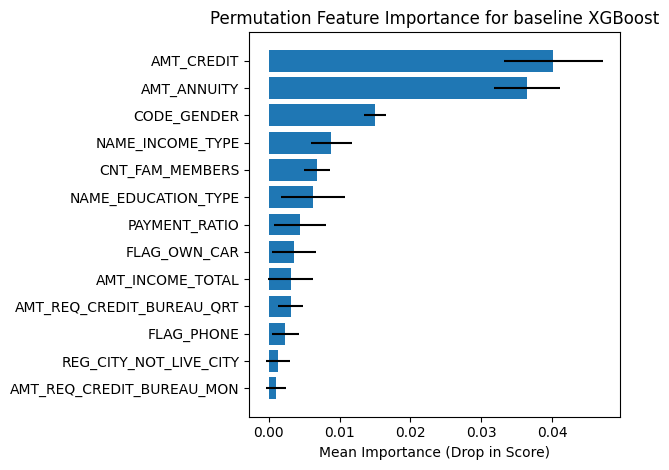

In [39]:
plt.barh(importance_df_xgb["feature"], importance_df_xgb["mean_importance"], xerr=importance_df_xgb["std_importance"])
plt.xlabel("Mean Importance (Drop in Score)")
plt.title("Permutation Feature Importance for baseline XGBoost")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [40]:
# feature importance for Random Forest Algorithm using Standardize data
result_rfc_std = permutation_importance(rfc_std, X_test, y_test, n_repeats=10, random_state = 42)
# Display importance
importance_df_rfc_std = pd.DataFrame({
    'feature': X.columns,\
    'mean_importance': result_rfc_std.importances_mean,\
    'std_importance': result_rfc_std.importances_std,\
}).sort_values(by='mean_importance', ascending=False)

print("Feature importance for Random Forest Algorithm using Standardize data")
importance_df_rfc_std

C:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature

Feature importance for Random Forest Algorithm using Standardize data


C:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


,feature,mean_importance,std_importance
5,NAME_INCOME_TYPE,0.009752,0.001674
6,NAME_EDUCATION_TYPE,0.005958,0.002416
1,FLAG_OWN_CAR,0.004079,0.001549
8,CNT_FAM_MEMBERS,0.003407,0.003296
0,CODE_GENDER,0.000000,0.000000
2,AMT_INCOME_TOTAL,0.000000,0.000000
3,AMT_CREDIT,0.000000,0.000000
4,AMT_ANNUITY,0.000000,0.000000
9,REG_CITY_NOT_LIVE_CITY,0.000000,0.000000
10,AMT_REQ_CREDIT_BUREAU_MON,-0.000218,0.000619


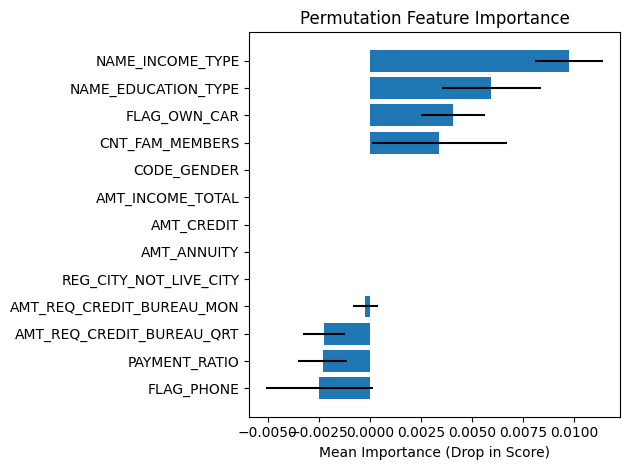

In [41]:
plt.barh(importance_df_rfc_std["feature"], importance_df_rfc_std["mean_importance"], xerr=importance_df_rfc_std["std_importance"])
plt.xlabel("Mean Importance (Drop in Score)")
plt.title("Permutation Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [42]:
# feature importance for Random Forest Algorithm using Standardize data
result_xgb_std = permutation_importance(xgb_std, X_test, y_test, n_repeats=10, random_state = 42)
# Display importance
importance_df_xgb_std = pd.DataFrame({
    'feature': X.columns,\
    'mean_importance': result_xgb_std.importances_mean,\
    'std_importance': result_xgb_std.importances_std,\
}).sort_values(by='mean_importance', ascending=False)

print("Feature importance for Random Forest Algorithm using Standardize data")
importance_df_xgb_std

Feature importance for Random Forest Algorithm using Standardize data


,feature,mean_importance,std_importance
5,NAME_INCOME_TYPE,0.039627,0.002841
8,CNT_FAM_MEMBERS,0.000688,0.004516
1,FLAG_OWN_CAR,0.000000,0.000000
2,AMT_INCOME_TOTAL,0.000000,0.000000
3,AMT_CREDIT,0.000000,0.000000
4,AMT_ANNUITY,0.000000,0.000000
7,FLAG_PHONE,0.000000,0.000000
9,REG_CITY_NOT_LIVE_CITY,0.000000,0.000000
11,AMT_REQ_CREDIT_BUREAU_QRT,-0.000151,0.000749
10,AMT_REQ_CREDIT_BUREAU_MON,-0.000336,0.001712


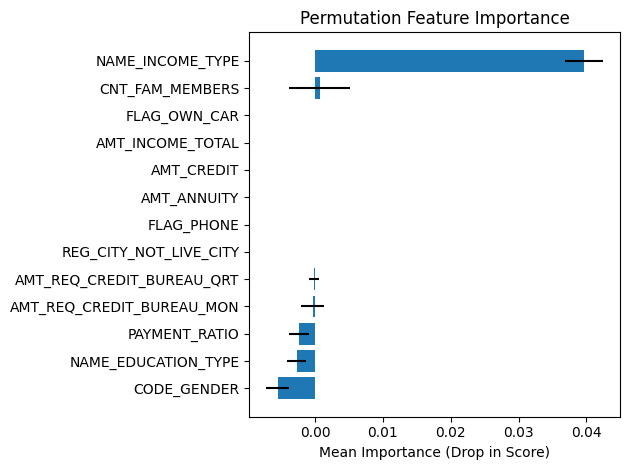

In [43]:
plt.barh(importance_df_xgb_std["feature"], importance_df_xgb_std["mean_importance"], xerr=importance_df_xgb_std["std_importance"])
plt.xlabel("Mean Importance (Drop in Score)")
plt.title("Permutation Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Recommendation & Communication

#### Suggest business actionables based on model insights.

##### Insight 1: Payment Ratio is a strong predictor. A minimum threshold must be set.

##### Insight 2: Key Drivers of Risk(credit amount, annuity, type of income, type of education). Re-calibrate credit scoring policy to weigh top risk features more heavily. Automate red-flag detection during onboarding.

##### Insight 3: Ensure credit approval criteria for segments with high default probability. Introduce tiered interest rate. Implement pre-approval counseling.

In [79]:
###

#### Executive Summary: Asset Financing Risk Prediction Initiative
##### A machine learning-based asset financing risk prediction model is built based on the growing need for proactive credit risk management. 
##### This model(xgboost) aim at identifying high risk customers at risk of default. This models leverage features such as: debt-to-income ratio, annuity, credit amount, income amount, etc.

#### Key Insights:

##### a) The model(xgboost) can identify high-risk segments based on features like credit amount, annuity, type of income, and payment ratio.

##### b) Behavioral and demographic features such as type of education, gender, etc significantly influence default probability.

##### c) Model overall performance highlighted the need for more significant features.

#### Business Implications & Actions:

##### a) For high-risk customers, optimization of return is recommended for risk-based pricing and tiered loan.

##### b) Operational teams can adopt the model outputs to priotize loan approvals, refine recovery strategies, and reduce portfolio-level default rates. 

##### c) The insights support the initialization of early warning systems, personalized credit offerings, and targeted customer engagement for repayment.

##### d) This initiative indicates a critical step toward data-driven lending, enabling smarter decisions, reduced credit losses, and enhanced financial inclusion.

#### Limitations

##### This project is still under development and will require identifying and introducing new features such as loan term, gross monthly income, etc; which are not available now.

##### Also, more experiments can be designed to improve the performance. To mention but a few:

##### 1) Change encoding type from label to one-hot encoding.
##### 2) Utilize lightgbm algorithm and compare with others.
##### 3) Introduce relevant features not capture in the data, which can be important for feature engineering.
##### 4) Engage hyper-parameter tuning after taking all the steps above.
